In [35]:
import numpy as np
import pandas as pd
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
import kagglehub

/kaggle/input/datasets/menegidio/iris-species/Iris.csv
/kaggle/input/datasets/menegidio/iris-species/database.sqlite


# Importação das Bibliotecas

In [36]:
from sklearn.model_selection import train_test_split #Criar dois grupos uma para teste e um para treino
from sklearn.svm import SVC # Usado para criar um Support Vector Machine vulgo base de todo notebook
from sklearn.metrics import accuracy_score #Criar meio para calcular a precisão dos resultados
import matplotlib.pyplot as plt # Usado para plotar graficos 
import seaborn as sns # Mais opções estéticas para gráficos

In [37]:
# - Usando Pandas para trazer o Banco de Dados e confirmar se ele importou certo os dados
iris_df = pd.read_csv('/kaggle/input/datasets/menegidio/iris-species/Iris.csv') 
iris_df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


# Análise Exploratória de Dados (EDA).

In [38]:
#Deleto as coluna 'Species' e'Id'simultaneamente na variavel de features já que não serão usadas como features
X = iris_df.drop(["Id", "Species"], axis=1, errors='ignore')


In [39]:
# Armazena as espécies das flores, que são o nosso objetivo de classificação
y = iris_df["Species"]

# Teste e Treino

In [40]:
# Divide os dados em treino (80%) e teste (20%) alocando eles em variaveis separadas, 
#usando random_state para garantir que o sorteio seja sempre o mesmo
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [41]:
#Cria uma modelo de MachineLearning SVM (usando o kernel linear)
model = SVC(kernel='linear')

In [42]:
model.fit(X_train, y_train)#Treina o modelo
y_pred = model.predict(X_test)# Faz as previsoes usando os dados dos teste

# Previsão e Avaliação

In [43]:
#Mostra a % da precisao do modelo testado
accuracy = accuracy_score(y_test, y_pred)
print(f'Precisao do modelo: {accuracy * 100:.2f}%')

Precisao do modelo: 100.00%


In [44]:
# Exibe as previsões do modelo e os valores reais para uma comparação visual
print("Valores preditos:", y_pred)
print("Valores reais:", y_test.values)

Valores preditos: ['Iris-versicolor' 'Iris-setosa' 'Iris-virginica' 'Iris-versicolor'
 'Iris-versicolor' 'Iris-setosa' 'Iris-versicolor' 'Iris-virginica'
 'Iris-versicolor' 'Iris-versicolor' 'Iris-virginica' 'Iris-setosa'
 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-versicolor'
 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor' 'Iris-virginica'
 'Iris-setosa' 'Iris-virginica' 'Iris-setosa' 'Iris-virginica'
 'Iris-virginica' 'Iris-virginica' 'Iris-virginica' 'Iris-virginica'
 'Iris-setosa' 'Iris-setosa']
Valores reais: ['Iris-versicolor' 'Iris-setosa' 'Iris-virginica' 'Iris-versicolor'
 'Iris-versicolor' 'Iris-setosa' 'Iris-versicolor' 'Iris-virginica'
 'Iris-versicolor' 'Iris-versicolor' 'Iris-virginica' 'Iris-setosa'
 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-versicolor'
 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor' 'Iris-virginica'
 'Iris-setosa' 'Iris-virginica' 'Iris-setosa' 'Iris-virginica'
 'Iris-virginica' 'Iris-virginica' 'Iris-virginica' 'Iris-virginica'
 

# Visuais com matplotlib e seaborn

In [45]:
#Com Pandas eu crio uma matriz já com os rótulos das linhas e colunas
#Pra realizar a comparação entre valores reais (linhas) e valores previstos (colunas).

cm = pd.crosstab(y_test, y_pred, rownames=['Real'], colnames=['Previsão'])

print("Matriz de Confusão:\n")
print(cm)

Matriz de Confusão:

Previsão         Iris-setosa  Iris-versicolor  Iris-virginica
Real                                                         
Iris-setosa               10                0               0
Iris-versicolor            0                9               0
Iris-virginica             0                0              11


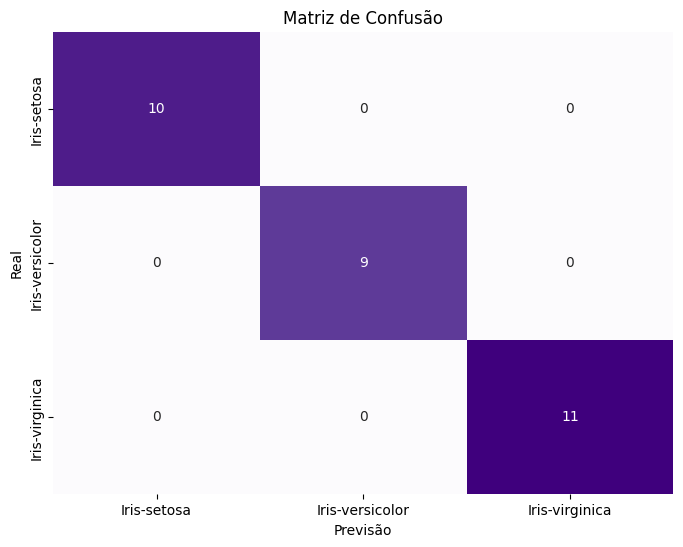

In [48]:
#Aqui eu gero a visualizção da matriz de forma gráfica
plt.figure(figsize=(8, 6))
nomes_especies = ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', cbar=False,
            xticklabels=nomes_especies, yticklabels=nomes_especies)

plt.xlabel('Previsão')
plt.ylabel('Real')
plt.title('Matriz de Confusão')
plt.show()

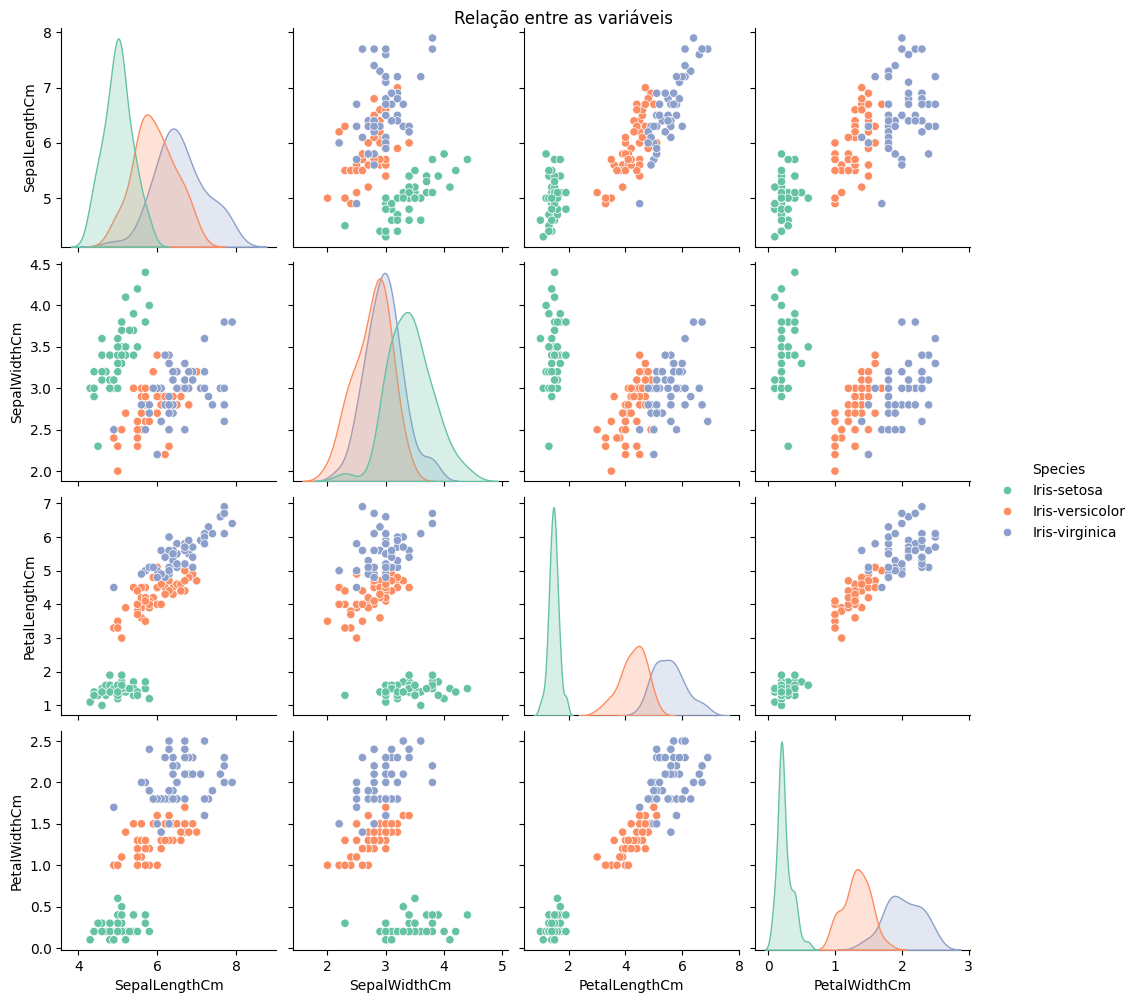

In [58]:
#Aqui usando o seaborn eu ploto um grafico mostrando todas as variaveis de especies do dataset
sns.pairplot(iris_df.drop("Id", axis=1), hue='Species', palette='Set2')
plt.suptitle("Relação entre as variáveis", y=1.0)
plt.show()

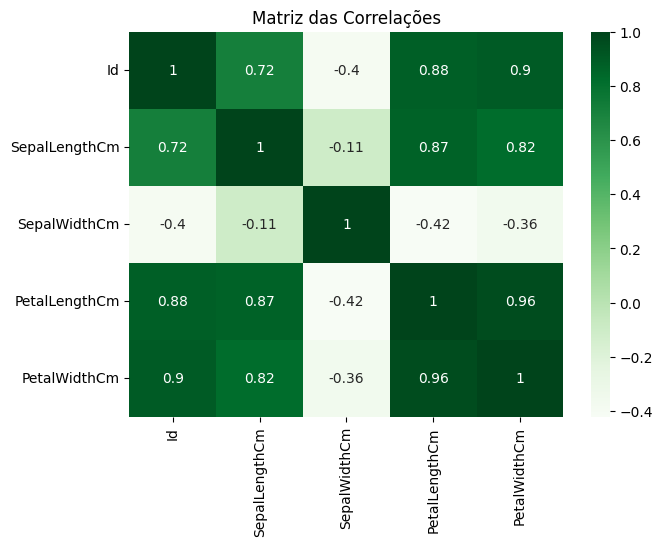

In [60]:
##Plota a matriz de correlação com valores numéricos para analisar a relação estatística entre os dados
plt.figure(figsize=(7,5))
sns.heatmap(iris_df.corr(numeric_only=True), annot=True, cmap='Greens')
plt.title("Matriz das Correlações")
plt.show()

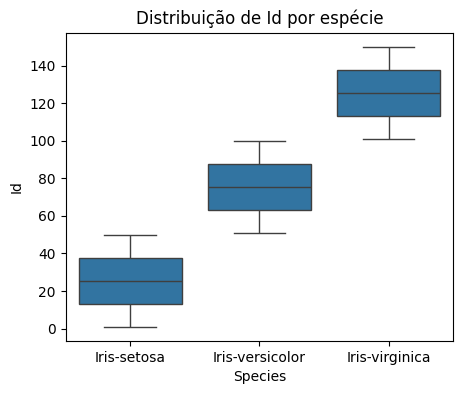

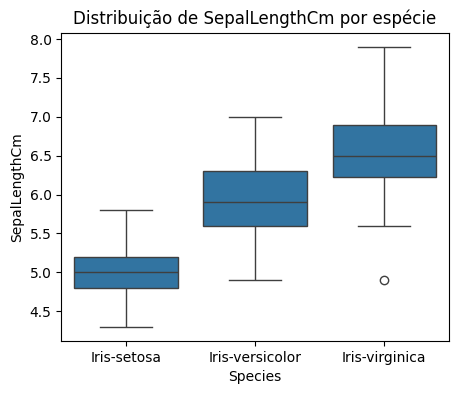

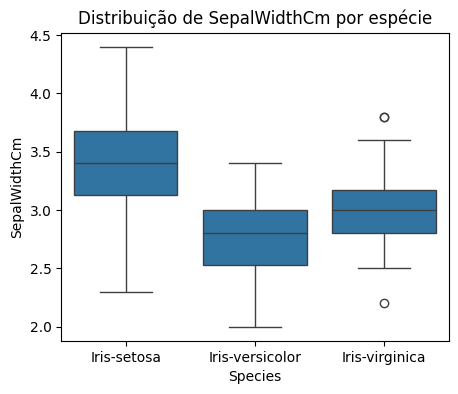

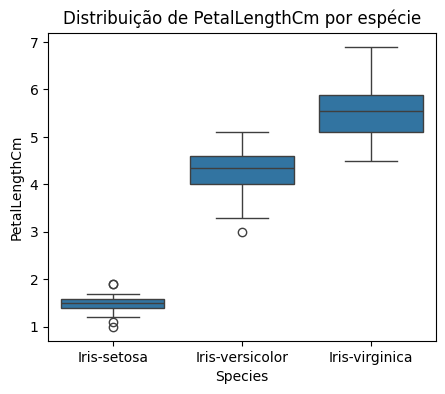

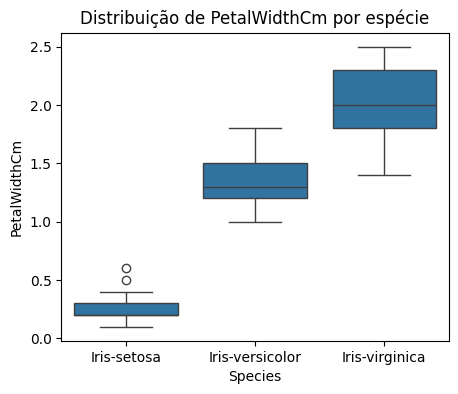

In [72]:
#Plota gráficos de caixa para examinar a dispersão, detectar valores discrepantes e comparar as espécies
#se utilizando de medianas e variações entre elas
for col in iris_df.columns[:-1]:
    plt.figure(figsize=(5,4))
    sns.boxplot(x='Species', y=col, data=iris_df)
    plt.title(f"Distribuição de {col} por espécie")
    plt.show()